/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


Text(0.5, 1.0, 'Avg Latency Varying RW Txn Ratio(buffer 1.25, scan-mix)')

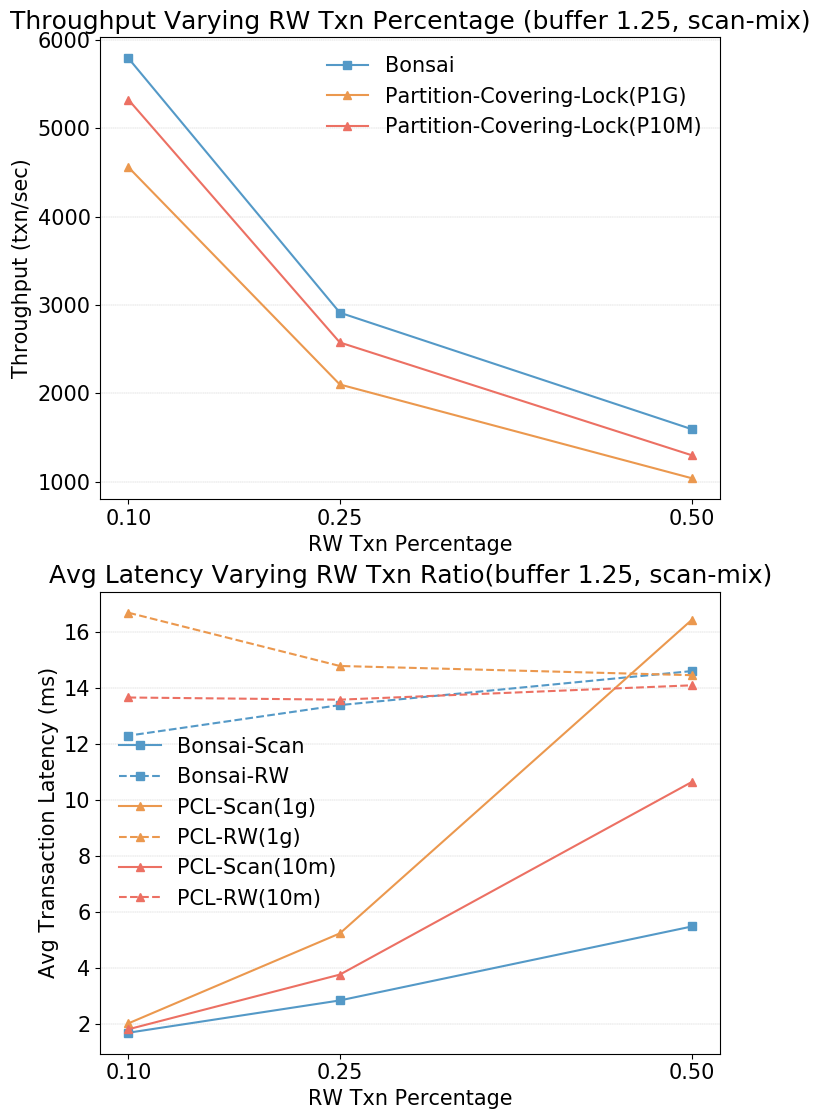

In [1]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
exp_next_key = "exp_mix_scan_10g_bonsai_test_demo"
exp_partition_lock = "exp_mix_scan_partition_lock_Psize_test_demo"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
df_next_key = apply_mask(df_next_key, [
    ["g_total_buf_sz", ["eq", 15000000000]]
])



data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 15000000000]]
])

        
df_partition_lock_1g = apply_mask(df_partition_lock, [
    ["g_partition_covering_lock_unit_sz", ["eq", 1000000]]
])
df_partition_lock_1g = df_partition_lock_1g.sort_values(by='rw_txn_perc_')


df_partition_lock_10m = apply_mask(df_partition_lock, [
    ["g_partition_covering_lock_unit_sz", ["eq", 10000]]
])
df_partition_lock_10m = df_partition_lock_10m.sort_values(by='rw_txn_perc_')

df_partition_lock_100k = apply_mask(df_partition_lock, [
    ["g_partition_covering_lock_unit_sz", ["eq", 100]]
])
df_partition_lock_100k = df_partition_lock_100k.sort_values(by='rw_txn_perc_')


# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_next_key["rw_txn_perc_"], 
        df_next_key["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_partition_lock_1g["rw_txn_perc_"], 
        df_partition_lock_1g["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="Partition-Covering-Lock(P1G)")

ax.plot(df_partition_lock_10m["rw_txn_perc_"], 
        df_partition_lock_10m["throughput_txn_per_sec"],
        color=line_colors["RED"],
        marker="^", label="Partition-Covering-Lock(P10M)")

# ax.plot(df_partition_lock_100k["rw_txn_perc_"], 
#         df_partition_lock_100k["throughput_txn_per_sec"],
#         color=line_colors["ORANGE"],
#         marker="^", label="Partition-Covering-Lock(P100K)")


# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["rw_txn_perc_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("RW Txn Percentage")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying RW Txn Percentage (buffer 1.25, scan-mix)")



ax = fig.add_subplot(6, 1, 2)


ax.plot(df_next_key["rw_txn_perc_"], 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")
ax.plot(df_next_key["rw_txn_perc_"], 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(df_partition_lock_1g["rw_txn_perc_"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock_1g["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan(1g)")

ax.plot(df_partition_lock_1g["rw_txn_perc_"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock_1g["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW(1g)", linestyle='dashed')


ax.plot(df_partition_lock_10m["rw_txn_perc_"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock_10m["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["RED"],
        marker="^", label="PCL-Scan(10m)")

ax.plot(df_partition_lock_10m["rw_txn_perc_"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock_10m["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["RED"],
        marker="^", label="PCL-RW(10m)", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["rw_txn_perc_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("RW Txn Percentage")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying RW Txn Ratio(buffer 1.25, scan-mix)")




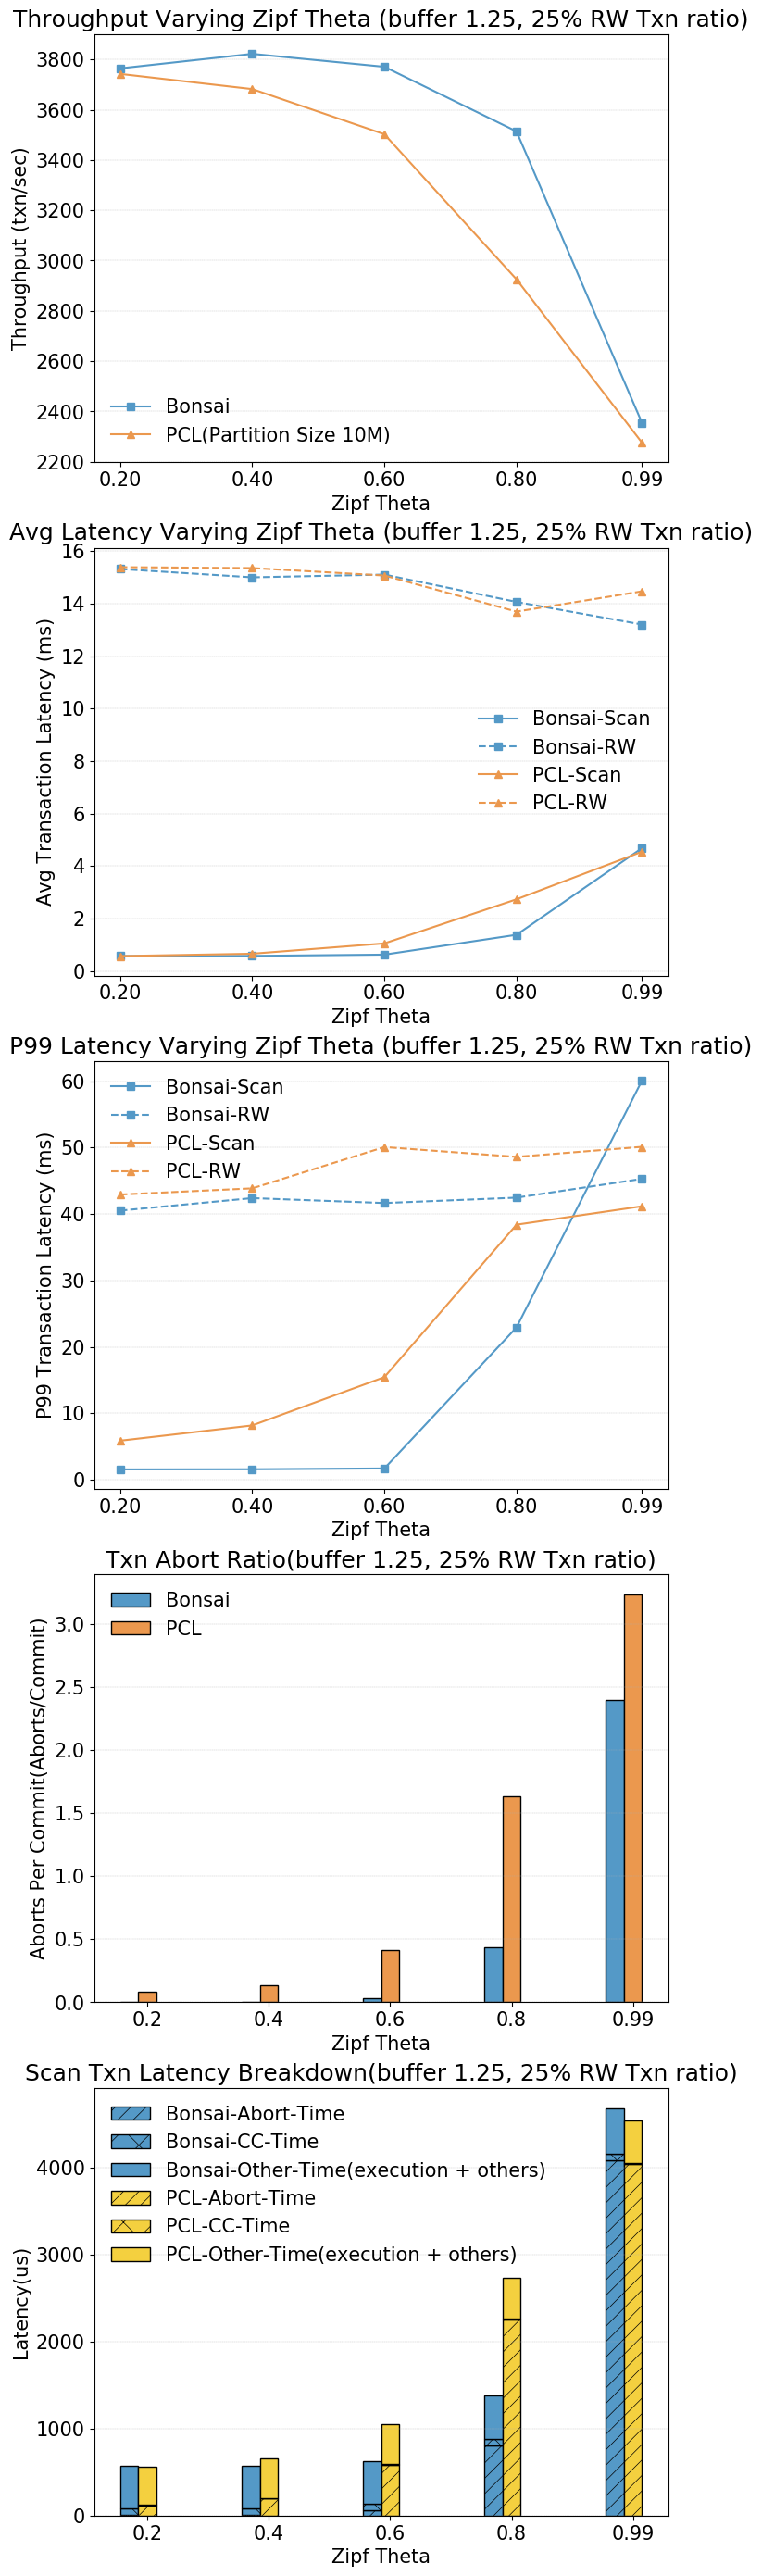

In [2]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
# idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
exp_next_key = "exp_mix_scan_10g_bonsai_test_demo_zipf"
exp_partition_lock = "exp_mix_scan_partition_lock_Psize_test_demo_zipf"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
df_next_key = df_next_key.sort_values(by='zipf_theta_')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = df_partition_lock.sort_values(by='zipf_theta_')

# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="PCL(Partition Size 10M)")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")



ax = fig.add_subplot(6, 1, 2)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")
ax.plot(df_next_key["zipf_theta_"], 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(df_partition_lock["zipf_theta_"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")


ax = fig.add_subplot(6, 1, 3)


# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["scan_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["rw_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW",linestyle='dashed')



ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["scan_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["rw_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Zipf Theta")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Zipf Theta (buffer 1.25, 25% RW Txn ratio)")


index = np.arange(len(df_next_key["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 4)


ax1.bar(index + 1 * bar_width, 
        df_next_key["abort_cnt_"]/df_next_key["txn_cnt_"] , width=bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_partition_lock["abort_cnt_"]/df_partition_lock["txn_cnt_"], width=bar_width, edgecolor='black',
        color=line_colors["ORANGE"],
        label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Txn Abort Ratio(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 5)

ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
        color=line_colors["BLUE"],
        label="Bonsai-Abort-Time")
ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_cc_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
        color=line_colors["BLUE"],
        label="Bonsai-CC-Time")
ax1.bar(index + 1 * bar_width, 
        df_next_key["avg_sum_scan_txn_latency (us)"] - df_next_key["avg_scan_abort_time_ (us)"] - df_next_key["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai-Other-Time(execution + others)")


ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
        color=line_colors["YELLOW"],
        label="PCL-Abort-Time")
ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_cc_time_ (us)"] , bottom=df_partition_lock["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
        color=line_colors["YELLOW"],
        label="PCL-CC-Time")
ax1.bar(index + 2 * bar_width, 
        df_partition_lock["avg_sum_scan_txn_latency (us)"] - df_partition_lock["avg_scan_abort_time_ (us)"] - df_partition_lock["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_partition_lock["avg_scan_abort_time_ (us)"], df_partition_lock["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
        color=line_colors["YELLOW"],
        label="PCL-Other-Time(execution + others)")

# ax1 = fig.add_subplot(6, 1, 5)
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
#         color=line_colors["BLUE"],
#         label="Bonsai-Abort-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_cc_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
#         color=line_colors["BLUE"],
#         label="Bonsai-CC-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_log_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], , bottom=[i+j for i, j in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black', hatch='o',
#         color=line_colors["BLUE"],
#         label="Bonsai-CC-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_sum_scan_txn_latency (us)"] - df_next_key["avg_log_time_ (us)"] - df_next_key["avg_scan_abort_time_ (us)"] - df_next_key["avg_cc_time_ (us)"], bottom=[i+j+m for i, j, m in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"], df_next_key["avg_log_time_ (us)"])], width=bar_width, edgecolor='black',
#         color=line_colors["BLUE"],
#         label="Bonsai-Other-Time(execution + others)")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
#         color=line_colors["YELLOW"],
#         label="PCL-Abort-Time")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_cc_time_ (us)"] , bottom=df_partition_lock["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
#         color=line_colors["YELLOW"],
#         label="PCL-CC-Time")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_sum_scan_txn_latency (us)"] - df_partition_lock["avg_scan_abort_time_ (us)"] - df_partition_lock["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_partition_lock["avg_scan_abort_time_ (us)"], df_partition_lock["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
#         color=line_colors["YELLOW"],
#         label="PCL-Other-Time(execution + others)")





# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["scan_abort_cnt_"]/df_partition_lock["scan_txn_cnt_"], bar_width, edgecolor='black',
#         color=line_colors["ORANGE"],
#         label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Latency(us)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Scan Txn Latency Breakdown(buffer 1.25, 25% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# ax1 = fig.add_subplot(6, 1, 6)


# ax1.bar(index + 1 * bar_width, 
#         df_next_key["rw_abort_cnt_"]/df_next_key["rw_txn_cnt_"] , bar_width,edgecolor='black',
#         color=line_colors["BLUE"],
#         label="Bonsai")

# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["rw_abort_cnt_"]/df_partition_lock["rw_txn_cnt_"], bar_width, edgecolor='black',
#         color=line_colors["ORANGE"],
#         label="PCL")

# # plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
# plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# # location = "upper left"
# location = "best"
# ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
# ax1.set_xlabel("Zipf Theta")
# # ax1.set_xscale('log')
# ax1.set_title("RW Txn Abort Ratio(theta 0.9, writeheavy)")
# #ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

